#ML Churn Prediction + SHAP Explainability

This notebook trains an XGBoost classifier to predict customer churn
and uses SHAP values to explain which features drive churn for each segment.

**Dataset:** IBM Telco Customer Churn (7,043 customers, 21 features)  
**Model:** XGBoost with class imbalance handling  
**Tools:** scikit-learn, XGBoost, SHAP

In [1]:
!pip install xgboost shap psycopg2-binary

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 88.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

## 1. Data Loading & Feature Engineering
Load the raw CSV and replicate the feature engineering done in SQL (Phase 2).


In [3]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [4]:
import io
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])
df['churn_value'] = (df['Churn'] == 'Yes').astype(int)
df['tenure_bucket'] = pd.cut(df['tenure'],
                              bins=[0, 12, 24, 72],
                              labels=['0-12m', '12-24m', '24m+'])
df['spend_tier'] = pd.cut(df['MonthlyCharges'],
                           bins=[0, 35, 65, 200],
                           labels=['Low', 'Medium', 'High'])
print(df.shape)
print(df['churn_value'].value_counts())

(7032, 24)
churn_value
0    5163
1    1869
Name: count, dtype: int64


## 2. Encoding & Train-Test Split
Encode categorical variables and split into 80/20 train/test sets,
stratified by churn to preserve class distribution.

In [7]:
feature_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
    'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
    'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
    'MonthlyCharges', 'TotalCharges'
]

X = df[feature_cols].copy()
y = df['churn_value']

le = LabelEncoder()
for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train size:', X_train.shape)
print('Test size:', X_test.shape)
print('Churn rate in test:', round(y_test.mean() * 100, 1), '%')

Train size: (5625, 19)
Test size: (1407, 19)
Churn rate in test: 26.6 %


## 3. Model Training
XGBoost with `scale_pos_weight` to handle class imbalance
(5163 non-churners vs 1869 churners).

In [8]:
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=5163/1869,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print('ROC-AUC:', round(roc_auc_score(y_test, y_prob), 3))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1033
           1       0.50      0.78      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.75      1407

ROC-AUC: 0.824


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [11:31:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## 4. SHAP Explainability
SHAP (SHapley Additive exPlanations) explains the contribution of each
feature to individual predictions — not just overall importance.

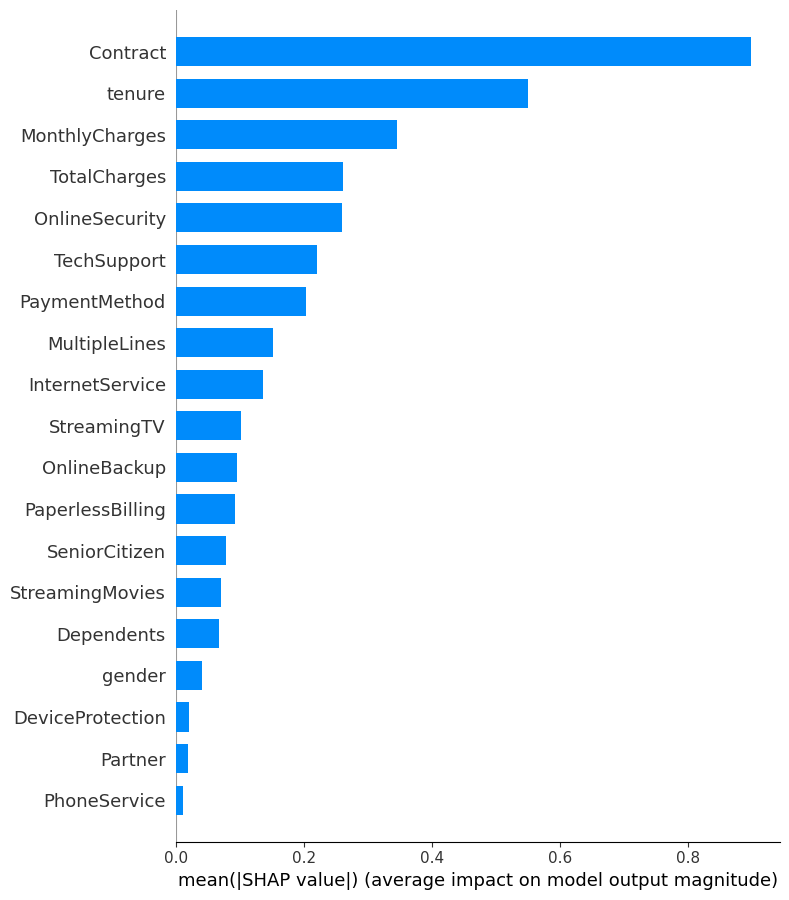

Saved shap_summary.png


In [9]:
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved shap_summary.png")

### Key Findings
- **Contract type** is the single biggest churn driver
- **Low tenure** (new customers) significantly increases churn risk
- **High monthly charges** push customers toward leaving
- Customers without **OnlineSecurity** or **TechSupport** churn more

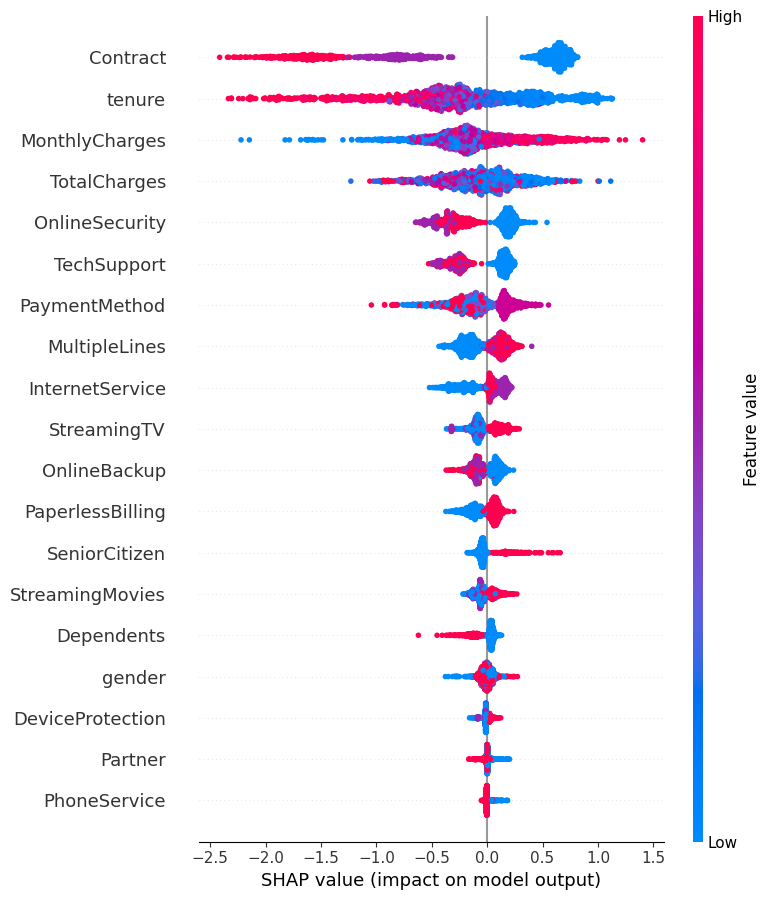

In [10]:
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('shap_dot.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Customer Risk Scores
Assign churn probability to every customer. Top 20 highest-risk customers
all share the same profile: month-to-month contract, new customer, high bill.


In [11]:
X_test_copy = X_test.copy()
X_test_copy['churn_probability'] = y_prob
X_test_copy['actual_churn'] = y_test.values
X_test_copy['predicted_churn'] = y_pred

high_risk = X_test_copy.sort_values('churn_probability', ascending=False).head(20)
print(high_risk[['tenure', 'Contract', 'MonthlyCharges', 'churn_probability', 'actual_churn']])

      tenure  Contract  MonthlyCharges  churn_probability  actual_churn
3380       1         0           95.10           0.979854             1
2753       1         0           95.65           0.978630             1
4585       1         0           85.05           0.972985             1
3159       3         0           94.85           0.970676             0
2246       1         0          102.45           0.970350             1
2631       7         0           99.25           0.969669             1
2797       3         0          100.95           0.968035             1
6240       1         0           93.30           0.966778             1
2464       1         0           77.15           0.965374             1
3727       3         0           96.60           0.962898             1
6839      11         0          100.75           0.961575             1
6231       1         0           76.40           0.956487             1
4678       2         0           94.20           0.952099       

In [12]:
full_pred = model.predict_proba(X)[:, 1]
df['churn_probability'] = full_pred
df['predicted_churn'] = model.predict(X)

df.to_csv('telco_with_predictions.csv', index=False)
files.download('telco_with_predictions.csv')
print("Downloaded successfully")

files.download('shap_summary.png')
files.download('shap_dot.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded successfully


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>